# Cuff-Less Blood Pressure Estimation: 100 Hz Pipeline with 10-Fold CV Optuna Tuning & Holdout Test Evaluation

This notebook implements an end-to-end Machine Learning pipeline for **Cuff-Less Non-Invasive Blood Pressure (BP) Estimation**:
- **Dataset Partitioning**: **80% Training Set** and **20% Holdout Test Set** (`train_test_split(test_size=0.20, random_state=42)`).
- **10-Fold Cross-Validation on Train Set**: Optuna Bayesian hyperparameter optimization over 10-Fold CV (`KFold(n_splits=10, shuffle=True, random_state=42)`) on the training set to maximize $R^2$ score.
- **Holdout Test Set Evaluation**: Models are evaluated on the unseen 20% Test Dataset using an ensemble of 10-Fold trained models.
- **Actual vs. Predicted Scatter Plots**: Rendered on the **Holdout Test Dataset** for Systolic (SBP), Diastolic (DBP), and Mean Arterial Pressure (MAP).
- **C Code Export**: Converted to native C code via `m2cgen` into the `../deploy/` directory for ESP32 hardware deployment.


In [1]:
import os
import sys
import json
import time
import warnings
import numpy as np
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt
import optuna
import m2cgen as m2c
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Styling for plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120

print("Libraries imported successfully.")
print("  - LightGBM version :", getattr(__import__('lightgbm'), '__version__', 'N/A'))
print("  - Optuna version   :", getattr(__import__('optuna'), '__version__', 'N/A'))


Libraries imported successfully.
  - LightGBM version : 4.7.0
  - Optuna version   : 4.9.0


/home/apt2736/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Load Filter Configuration JSON


In [2]:
CONFIG_PATH = "../config/filter_config.json"
DATA_DIR = "../Cuff-less Non-invasive Blood Pressure Estimation Data Set"

with open(CONFIG_PATH, "r") as f:
    filter_config = json.load(f)

print("=== Filter Configuration JSON Loaded ===")
print(json.dumps(filter_config, indent=2))

TARGET_FS = filter_config["downsampling"]["target_fs"]
DECIMATION_FACTOR = filter_config["downsampling"]["decimation_factor"]
MEDIAN_KERNEL = filter_config["ppg_preprocessing"]["median_filter"]["kernel_size"]

PPG_LOWCUT = filter_config["ppg_preprocessing"]["bandpass_filter"]["lowcut_hz"]
PPG_HIGHCUT = filter_config["ppg_preprocessing"]["bandpass_filter"]["highcut_hz"]
PPG_ORDER = filter_config["ppg_preprocessing"]["bandpass_filter"]["order"]

ECG_LOWCUT = filter_config["ecg_preprocessing"]["bandpass_filter"]["lowcut_hz"]
ECG_HIGHCUT = filter_config["ecg_preprocessing"]["bandpass_filter"]["highcut_hz"]
ECG_ORDER = filter_config["ecg_preprocessing"]["bandpass_filter"]["order"]

all_subjects = list(range(1, 27))


=== Filter Configuration JSON Loaded ===
{
  "dataset": {
    "original_fs": 1000.0,
    "window_sec": 30
  },
  "downsampling": {
    "target_fs": 100.0,
    "decimation_factor": 10,
    "method": "iir",
    "zero_phase": true
  },
  "ppg_preprocessing": {
    "median_filter": {
      "window_ms": 30.0,
      "kernel_size": 3
    },
    "normalization": {
      "method": "min_max",
      "range": [
        0.0,
        1.0
      ]
    },
    "bandpass_filter": {
      "lowcut_hz": 0.5,
      "highcut_hz": 8.0,
      "order": 2,
      "filter_type": "butterworth",
      "zero_phase": true
    }
  },
  "ecg_preprocessing": {
    "bandpass_filter": {
      "lowcut_hz": 0.5,
      "highcut_hz": 35.0,
      "order": 3,
      "filter_type": "butterworth",
      "zero_phase": true
    }
  }
}


## Step 2 & 3: Downsample FIRST (1000 Hz -> 100 Hz) & 100 Hz Filtering


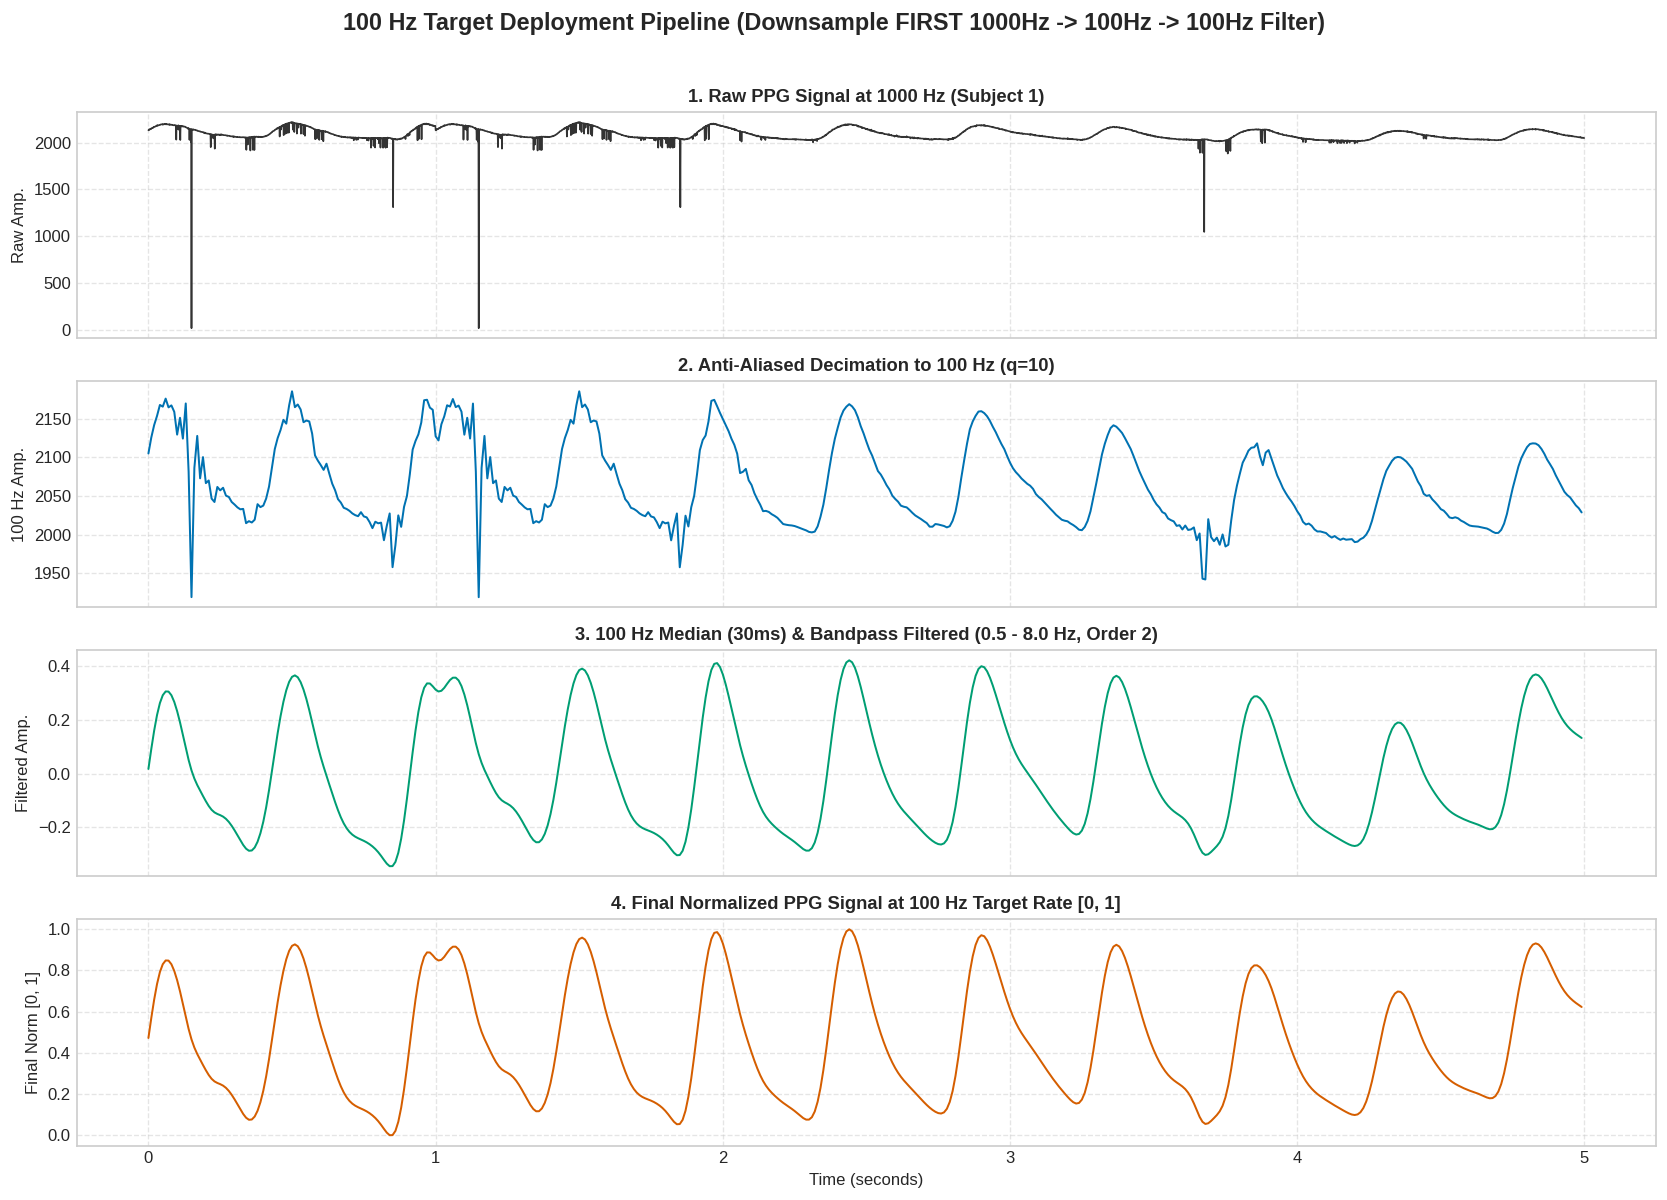

In [3]:
def preprocess_ppg_100hz(raw_1000hz, target_fs=100.0, dec_factor=10, median_kernel=3, lowcut=0.5, highcut=8.0, order=2):
    ds_100hz = signal.decimate(raw_1000hz, q=dec_factor, ftype='iir', zero_phase=True)
    med_filtered = signal.medfilt(ds_100hz, kernel_size=median_kernel)
    
    min_m, max_m = np.min(med_filtered), np.max(med_filtered)
    norm_med = (med_filtered - min_m) / (max_m - min_m) if max_m > min_m else np.zeros_like(med_filtered)
    
    b, a = signal.butter(order, [lowcut, highcut], btype='bandpass', fs=target_fs)
    iir_filtered = signal.filtfilt(b, a, norm_med)
    
    min_i, max_i = np.min(iir_filtered), np.max(iir_filtered)
    final_norm = (iir_filtered - min_i) / (max_i - min_i) if max_i > min_i else np.zeros_like(iir_filtered)
    
    return ds_100hz, med_filtered, iir_filtered, final_norm

with open(os.path.join(DATA_DIR, "1.json")) as f:
    sub1_data = json.load(f)

sample_raw_1000 = np.array(sub1_data["data_PPG"][:5000], dtype=float)
ds_100hz, med_filtered, iir_filtered, final_norm = preprocess_ppg_100hz(sample_raw_1000)

time_1000 = np.arange(len(sample_raw_1000)) / 1000.0
time_100 = np.arange(len(ds_100hz)) / 100.0

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(time_1000, sample_raw_1000, color='#333333', linewidth=1.0)
axes[0].set_title("1. Raw PPG Signal at 1000 Hz (Subject 1)", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Raw Amp.")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(time_100, ds_100hz, color='#0072B2', linewidth=1.2)
axes[1].set_title("2. Anti-Aliased Decimation to 100 Hz (q=10)", fontsize=11, fontweight='bold')
axes[1].set_ylabel("100 Hz Amp.")
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].plot(time_100, iir_filtered, color='#009E73', linewidth=1.2)
axes[2].set_title("3. 100 Hz Median (30ms) & Bandpass Filtered (0.5 - 8.0 Hz, Order 2)", fontsize=11, fontweight='bold')
axes[2].set_ylabel("Filtered Amp.")
axes[2].grid(True, linestyle='--', alpha=0.5)

axes[3].plot(time_100, final_norm, color='#D55E00', linewidth=1.2)
axes[3].set_title("4. Final Normalized PPG Signal at 100 Hz Target Rate [0, 1]", fontsize=11, fontweight='bold')
axes[3].set_xlabel("Time (seconds)")
axes[3].set_ylabel("Final Norm [0, 1]")
axes[3].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("100 Hz Target Deployment Pipeline (Downsample FIRST 1000Hz -> 100Hz -> 100Hz Filter)", fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("../plots/ppg_4stage_preprocessing_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


## Step 4: 100 Hz Feature Extraction (29 Refined PWA, Energy & PAT Features)


In [4]:
def extract_dataset_features_100hz(subject_list, window_sec=30):
    fs = TARGET_FS
    b_p, a_p = signal.butter(PPG_ORDER, [PPG_LOWCUT, PPG_HIGHCUT], btype='bandpass', fs=fs)
    b_e, a_e = signal.butter(ECG_ORDER, [ECG_LOWCUT, ECG_HIGHCUT], btype='bandpass', fs=fs)
    records = []
    
    for sub_id in subject_list:
        file_path = os.path.join(DATA_DIR, f"{sub_id}.json")
        if not os.path.exists(file_path): continue
        with open(file_path, "r") as f: data = json.load(f)
            
        ppg_raw_1000 = np.array(data["data_PPG"], dtype=float)
        ecg_raw_1000 = np.array(data["data_ECG"], dtype=float)
        bp_list = [b_dict for b_dict in data["data_BP"] if b_dict.get("SBP", 0) > 0 and b_dict.get("DBP", 0) > 0]
        if not bp_list: continue
            
        ppg_100 = signal.decimate(ppg_raw_1000, q=DECIMATION_FACTOR, ftype='iir', zero_phase=True)
        ecg_100 = signal.decimate(ecg_raw_1000, q=DECIMATION_FACTOR, ftype='iir', zero_phase=True)
        
        K = len(bp_list)
        seg_len = len(ppg_100) // K
        
        for k, bp_dict in enumerate(bp_list):
            p_seg = ppg_100[k * seg_len : (k + 1) * seg_len]
            e_seg = ecg_100[k * seg_len : (k + 1) * seg_len]
            win_len = int(window_sec * fs)
            step = win_len // 2
            if len(p_seg) < win_len: continue
                
            for w_start in range(0, len(p_seg) - win_len + 1, step):
                p_w = p_seg[w_start : w_start + win_len]
                e_w = e_seg[w_start : w_start + win_len]
                
                p_med = signal.medfilt(p_w, kernel_size=MEDIAN_KERNEL)
                p_min, p_max = np.min(p_med), np.max(p_med)
                if p_max <= p_min: continue
                p_norm1 = (p_med - p_min) / (p_max - p_min)
                
                p_filt = signal.filtfilt(b_p, a_p, p_norm1)
                p_min2, p_max2 = np.min(p_filt), np.max(p_filt)
                if p_max2 <= p_min2: continue
                w_final_norm = (p_filt - p_min2) / (p_max2 - p_min2)
                
                e_filt = signal.filtfilt(b_e, a_e, e_w)
                
                ppg_mean = float(np.mean(w_final_norm))
                ppg_var = float(np.var(w_final_norm))
                ppg_abs_energy = float(np.sum(w_final_norm ** 2))
                
                v_ppg = np.gradient(w_final_norm)
                a_ppg = np.gradient(v_ppg)
                
                ecg_peaks, _ = signal.find_peaks(e_filt, distance=int(0.4 * fs), prominence=np.std(e_filt) * 0.8)
                ppg_peaks, _ = signal.find_peaks(w_final_norm, distance=int(0.4 * fs), prominence=0.08)
                
                if len(ecg_peaks) < 5 or len(ppg_peaks) < 5: continue
                
                pat_f_list, pat_d_list, pat_p_list = [], [], []
                
                for r_p in ecg_peaks:
                    next_p = ppg_peaks[ppg_peaks > r_p]
                    if len(next_p) > 0:
                        p_idx = next_p[0]
                        delay_p = (p_idx - r_p) / fs * 1000.0
                        if 50 < delay_p < 600:
                            search_s = max(0, p_idx - int(0.3 * fs))
                            foot_i = search_s + np.argmin(w_final_norm[search_s:p_idx])
                            delay_f = (foot_i - r_p) / fs * 1000.0
                            
                            if foot_i < p_idx:
                                d_i = foot_i + np.argmax(v_ppg[foot_i:p_idx])
                                delay_d = (d_i - r_p) / fs * 1000.0
                            else:
                                delay_d = (delay_f + delay_p) / 2.0
                                
                            pat_p_list.append(delay_p)
                            pat_f_list.append(delay_f)
                            pat_d_list.append(delay_d)
                            
                if len(pat_p_list) < 3: continue
                
                pat_p_mean = float(np.mean(pat_p_list))
                pat_f_mean = float(np.mean(pat_f_list))
                pat_d_mean = float(np.mean(pat_d_list))
                
                ibi_ms = float(np.mean(np.diff(ppg_peaks))) / fs * 1000.0
                rr_sec = ibi_ms / 1000.0
                
                pat_f_bazett = float(pat_f_mean / np.sqrt(rr_sec + 1e-5))
                pat_d_bazett = float(pat_d_mean / np.sqrt(rr_sec + 1e-5))
                pat_p_bazett = float(pat_p_mean / np.sqrt(rr_sec + 1e-5))
                pat_f_fridericia = float(pat_f_mean / (rr_sec ** (1.0 / 3.0) + 1e-5))
                
                log_pat_f = float(np.log(pat_f_mean)) if pat_f_mean > 0 else 0.0
                inv_pat_f = float(1.0 / pat_f_mean) if pat_f_mean > 0 else 0.0
                inv_pat_f2 = float(1.0 / (pat_f_mean ** 2 + 1e-5))
                inv_pat_d = float(1.0 / pat_d_mean) if pat_d_mean > 0 else 0.0
                inv_pat_p = float(1.0 / pat_p_mean) if pat_p_mean > 0 else 0.0
                
                delta_pat_pf = float(pat_p_mean - pat_f_mean)
                delta_pat_df = float(pat_d_mean - pat_f_mean)
                ratio_pf = float(pat_p_mean / (pat_f_mean + 1e-5))
                ratio_df = float(pat_d_mean / (pat_f_mean + 1e-5))
                ratio_pd = float(pat_p_mean / (pat_d_mean + 1e-5))
                
                slope_pf = float(1.0 / (delta_pat_pf + 1e-5))
                slope_df = float(1.0 / (delta_pat_df + 1e-5))
                
                v_max = float(np.max(v_ppg))
                v_min = float(np.min(v_ppg))
                a_max = float(np.max(a_ppg))
                a_min = float(np.min(a_ppg))
                
                pulse_widths_50 = []
                pulse_widths_25 = []
                pulse_widths_75 = []
                systolic_times = []
                diastolic_times = []
                area_ratios = []
                aix_list = []
                
                for i in range(len(ppg_peaks) - 1):
                    p1 = ppg_peaks[i]
                    p2 = ppg_peaks[i+1]
                    pulse = w_final_norm[p1:p2]
                    if len(pulse) < int(0.4 * fs): continue
                    
                    foot_rel = np.argmin(w_final_norm[max(0, p1 - int(0.2*fs)) : p1])
                    t_foot = max(0, p1 - int(0.2*fs)) + foot_rel
                    
                    t_sys = (p1 - t_foot) / fs * 1000.0
                    t_dia = (p2 - p1) / fs * 1000.0
                    systolic_times.append(t_sys)
                    diastolic_times.append(t_dia)
                    
                    p_max_val = w_final_norm[p1]
                    p_min_val = w_final_norm[t_foot]
                    h_range = p_max_val - p_min_val
                    if h_range > 0:
                        pw50 = np.sum((pulse - p_min_val) >= 0.5 * h_range) / fs * 1000.0
                        pw25 = np.sum((pulse - p_min_val) >= 0.25 * h_range) / fs * 1000.0
                        pw75 = np.sum((pulse - p_min_val) >= 0.75 * h_range) / fs * 1000.0
                        pulse_widths_50.append(pw50)
                        pulse_widths_25.append(pw25)
                        pulse_widths_75.append(pw75)
                        
                    v_pulse = v_ppg[p1:p2]
                    if len(v_pulse) > 3:
                        notch_rel = p1 + np.argmax(v_pulse[2:]) + 2
                        area_sys = np.trapezoid(w_final_norm[t_foot:notch_rel])
                        area_dia = np.trapezoid(w_final_norm[notch_rel:p2])
                        if area_sys > 0:
                            area_ratios.append(area_dia / area_sys)
                        if notch_rel < p2 - 2:
                            d_peak_val = np.max(w_final_norm[notch_rel:p2])
                            aix = d_peak_val / (p_max_val + 1e-5)
                            aix_list.append(aix)
                            
                mean_pw50 = float(np.mean(pulse_widths_50)) if len(pulse_widths_50) > 0 else 0.0
                mean_pw25 = float(np.mean(pulse_widths_25)) if len(pulse_widths_25) > 0 else 0.0
                mean_pw75 = float(np.mean(pulse_widths_75)) if len(pulse_widths_75) > 0 else 0.0
                mean_tsys = float(np.mean(systolic_times)) if len(systolic_times) > 0 else 0.0
                mean_tdia = float(np.mean(diastolic_times)) if len(diastolic_times) > 0 else 0.0
                k_val = float(mean_tsys / (mean_tdia + 1e-5))
                mean_area_ratio = float(np.mean(area_ratios)) if len(area_ratios) > 0 else 0.0
                mean_aix = float(np.mean(aix_list)) if len(aix_list) > 0 else 0.0
                
                records.append({
                    'subject_id': sub_id,
                    'ppg_mean': ppg_mean, 'ppg_var': ppg_var, 'ppg_abs_energy': ppg_abs_energy,
                    'PAT_f': pat_f_mean, 'PAT_d': pat_d_mean, 'PAT_p': pat_p_mean,
                    'pat_f_bazett': pat_f_bazett, 'pat_d_bazett': pat_d_bazett, 'pat_p_bazett': pat_p_bazett, 'pat_f_fridericia': pat_f_fridericia,
                    'log_pat_f': log_pat_f,
                    'inv_PAT_f': inv_pat_f, 'inv_PAT_f2': inv_pat_f2,
                    'inv_PAT_d': inv_pat_d,
                    'inv_PAT_p': inv_pat_p,
                    'delta_PAT_pf': delta_pat_pf, 'delta_PAT_df': delta_pat_df,
                    'ratio_pf': ratio_pf, 'ratio_df': ratio_df, 'ratio_pd': ratio_pd,
                    'slope_pf': slope_pf, 'slope_df': slope_df,
                    'v_max': v_max, 'v_min': v_min, 'a_max': a_max, 'a_min': a_min,
                    'pw50': mean_pw50, 'pw25': mean_pw25, 'pw75': mean_pw75,
                    'k_val': k_val, 'area_ratio': mean_area_ratio, 'AIx': mean_aix,
                    'SBP': float(bp_dict["SBP"]),
                    'DBP': float(bp_dict["DBP"]),
                    'MAP': float(bp_dict["DBP"] + (bp_dict["SBP"] - bp_dict["DBP"]) / 3.0)
                })
                
    return pd.DataFrame(records)

print("Extracting 100 Hz features across all 26 dataset subjects...")
df_all = extract_dataset_features_100hz(all_subjects)
print(f"Extracted {len(df_all)} total 100 Hz dataset samples.")


Extracting 100 Hz features across all 26 dataset subjects...


Extracted 415 total 100 Hz dataset samples.


## Step 5: 80% Train / 20% Test Partition & 10-Fold CV Optuna Optimization

Partitioning dataset into **80% Train Set** and **20% Holdout Test Set**:
1. **10-Fold CV Tuning**: Optuna tunes LightGBM hyperparameters on the Training Set (`X_train`, `y_train`) using 10-Fold Cross-Validation.
2. **Holdout Test Prediction**: Ensembled prediction on `X_test` (averaging predictions across the 10 trained fold models) and evaluating on `y_test`.


In [5]:
feature_cols = [c for c in df_all.columns if c not in ['subject_id', 'SBP', 'DBP', 'MAP']]
X = df_all[feature_cols].fillna(0.0).values

df_train, df_test = train_test_split(df_all, test_size=0.20, random_state=42)
X_train = df_train[feature_cols].fillna(0.0).values
X_test  = df_test[feature_cols].fillna(0.0).values

print(f"Dataset Partitioning: Train Set = {len(df_train)} samples (80%) | Holdout Test Set = {len(df_test)} samples (20%)")

kf = KFold(n_splits=10, shuffle=True, random_state=42)

best_lgbm_params = {}
train_oof_preds = {}
test_preds_dict = {}
fold_models_dict = {}

for target in ['SBP', 'DBP', 'MAP']:
    y_train = df_train[target].values
    y_test  = df_test[target].values
    
    print(f"--- Running 10-Fold CV Optuna Optimization on Train Set ({target} Target) ---")
    
    def objective_lgbm(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 80, 250),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'num_leaves': trial.suggest_int('num_leaves', 8, 64),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': 42,
            'verbose': -1
        }
        oof = np.zeros(len(y_train))
        for tr_idx, val_idx in kf.split(X_train):
            m = LGBMRegressor(**params).fit(X_train[tr_idx], y_train[tr_idx])
            oof[val_idx] = m.predict(X_train[val_idx])
        return r2_score(y_train, oof)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective_lgbm, n_trials=40)
    best_lgbm_params[target] = study.best_params
    print(f"  Best 10-Fold Train OOF R2 Score: {study.best_value:.4f}")
    
    best_p = study.best_params.copy()
    best_p.update({'random_state': 42, 'verbose': -1})
    
    oof_train = np.zeros(len(y_train))
    test_preds_folds = np.zeros((10, len(y_test)))
    fold_models = []
    
    for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
        lgbm_fold = LGBMRegressor(**best_p).fit(X_train[tr_idx], y_train[tr_idx])
        oof_train[val_idx] = lgbm_fold.predict(X_train[val_idx])
        test_preds_folds[fold_idx, :] = lgbm_fold.predict(X_test)
        fold_models.append(lgbm_fold)
        
    y_test_pred = np.mean(test_preds_folds, axis=0)
    
    train_oof_preds[target] = oof_train
    test_preds_dict[target] = y_test_pred
    fold_models_dict[target] = fold_models

summary_rows = []
for target in ['SBP', 'DBP', 'MAP']:
    y_tr = df_train[target].values
    y_te = df_test[target].values
    y_tr_pred = train_oof_preds[target]
    y_te_pred = test_preds_dict[target]
    
    summary_rows.append({
        'Target': target,
        'Train OOF MAE': mean_absolute_error(y_tr, y_tr_pred),
        'Train OOF R2': r2_score(y_tr, y_tr_pred),
        'Test Set MAE (mmHg)': mean_absolute_error(y_te, y_te_pred),
        'Test Set RMSE (mmHg)': root_mean_squared_error(y_te, y_te_pred),
        'Test Set R2 Score': r2_score(y_te, y_te_pred)
    })

df_summary = pd.DataFrame(summary_rows)
print("\n=== Holdout Test Set Performance Summary (10-Fold CV Ensemble) ===")
display(df_summary)


Dataset Partitioning: Train Set = 332 samples (80%) | Holdout Test Set = 83 samples (20%)
--- Running 10-Fold CV Optuna Optimization on Train Set (SBP Target) ---


  Best 10-Fold Train OOF R2 Score: 0.7669


--- Running 10-Fold CV Optuna Optimization on Train Set (DBP Target) ---


  Best 10-Fold Train OOF R2 Score: 0.6050


--- Running 10-Fold CV Optuna Optimization on Train Set (MAP Target) ---


  Best 10-Fold Train OOF R2 Score: 0.7496



=== Holdout Test Set Performance Summary (10-Fold CV Ensemble) ===


,Target,Train OOF MAE,Train OOF R2,Test Set MAE (mmHg),Test Set RMSE (mmHg),Test Set R2 Score
0,SBP,7.203614,0.766932,7.277828,9.285494,0.743639
1,DBP,4.154276,0.604978,4.310368,5.791903,0.648777
2,MAP,4.239696,0.749578,4.402737,6.256439,0.702480


## Step 6: Actual vs. Predicted Scatter Plots on HOLDOUT TEST DATASET

These 1:1 scatter plots display model performance when evaluated on the **unseen 20% Holdout Test Dataset** using the 10-Fold Cross-Validation ensembled LightGBM model.


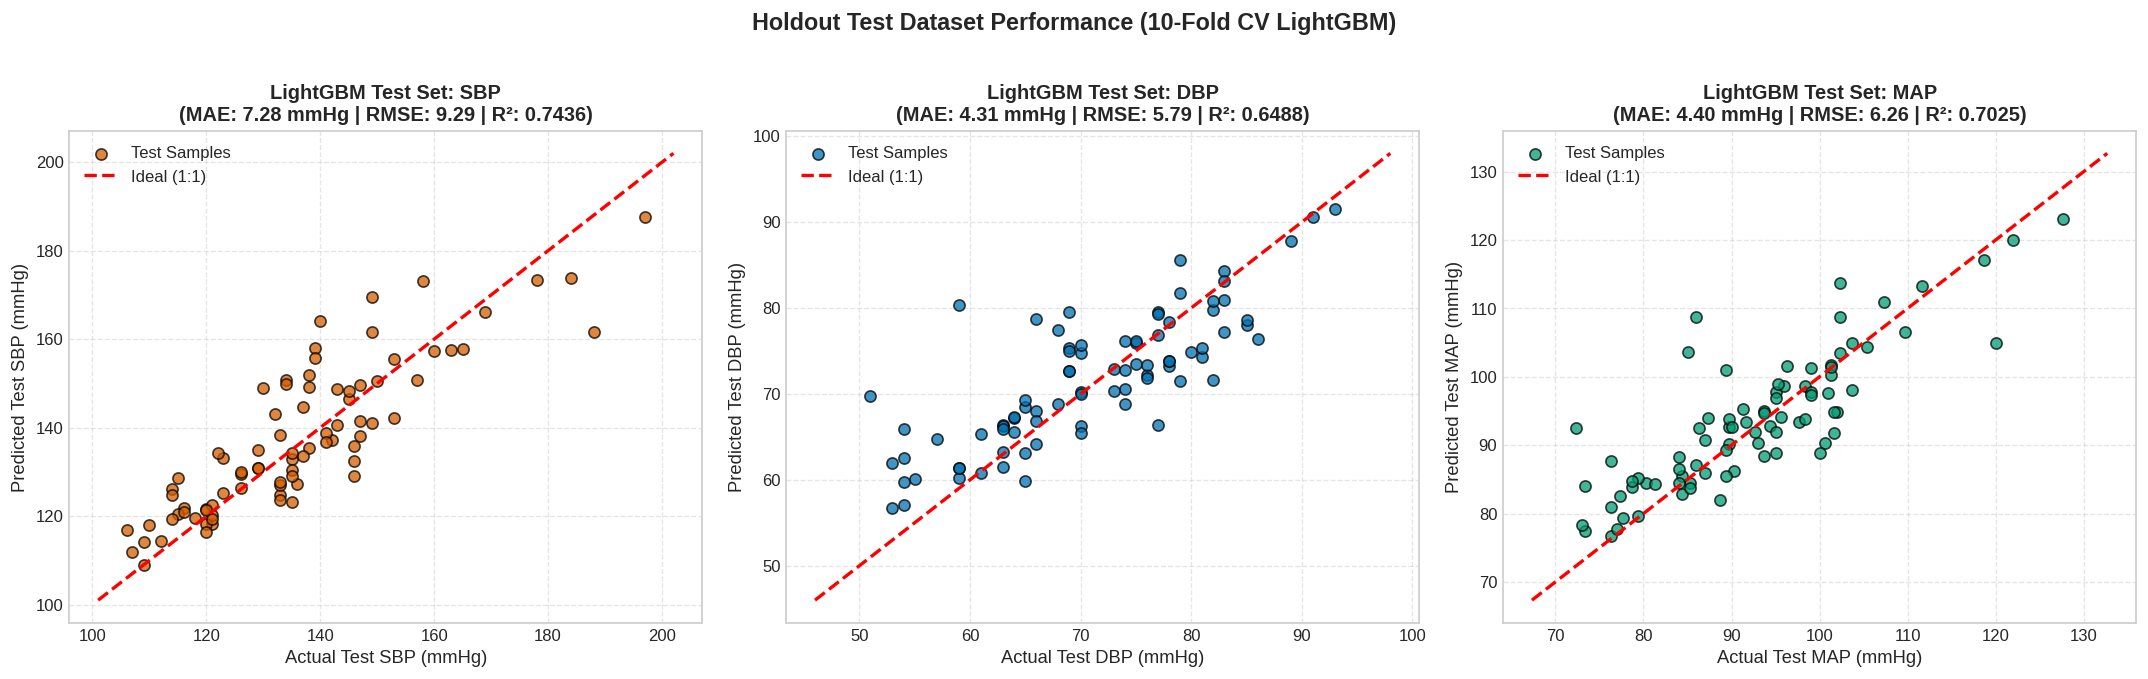

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

colors = {'SBP': '#D55E00', 'DBP': '#0072B2', 'MAP': '#009E73'}

for col_idx, target in enumerate(['SBP', 'DBP', 'MAP']):
    y_true_test = df_test[target].values
    y_pred_test = test_preds_dict[target]
    
    t_mae = mean_absolute_error(y_true_test, y_pred_test)
    t_rmse = root_mean_squared_error(y_true_test, y_pred_test)
    t_r2 = r2_score(y_true_test, y_pred_test)
    
    axes[col_idx].scatter(y_true_test, y_pred_test, color=colors[target], alpha=0.75, edgecolors='k', s=45, label='Test Samples')
    min_v = min(np.min(y_true_test), np.min(y_pred_test)) - 5
    max_v = max(np.max(y_true_test), np.max(y_pred_test)) + 5
    axes[col_idx].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Ideal (1:1)')
    
    axes[col_idx].set_title(f"LightGBM Test Set: {target}\n(MAE: {t_mae:.2f} mmHg | RMSE: {t_rmse:.2f} | R²: {t_r2:.4f})", fontsize=12, fontweight='bold')
    axes[col_idx].set_xlabel(f"Actual Test {target} (mmHg)", fontsize=11)
    axes[col_idx].set_ylabel(f"Predicted Test {target} (mmHg)", fontsize=11)
    axes[col_idx].legend(loc='upper left')
    axes[col_idx].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Holdout Test Dataset Performance (10-Fold CV LightGBM)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../plots/lightgbm_actual_vs_predicted.png", dpi=300, bbox_inches='tight')
plt.show()


## Step 7: Normalized Feature Importance Ranking (100 Hz LightGBM)


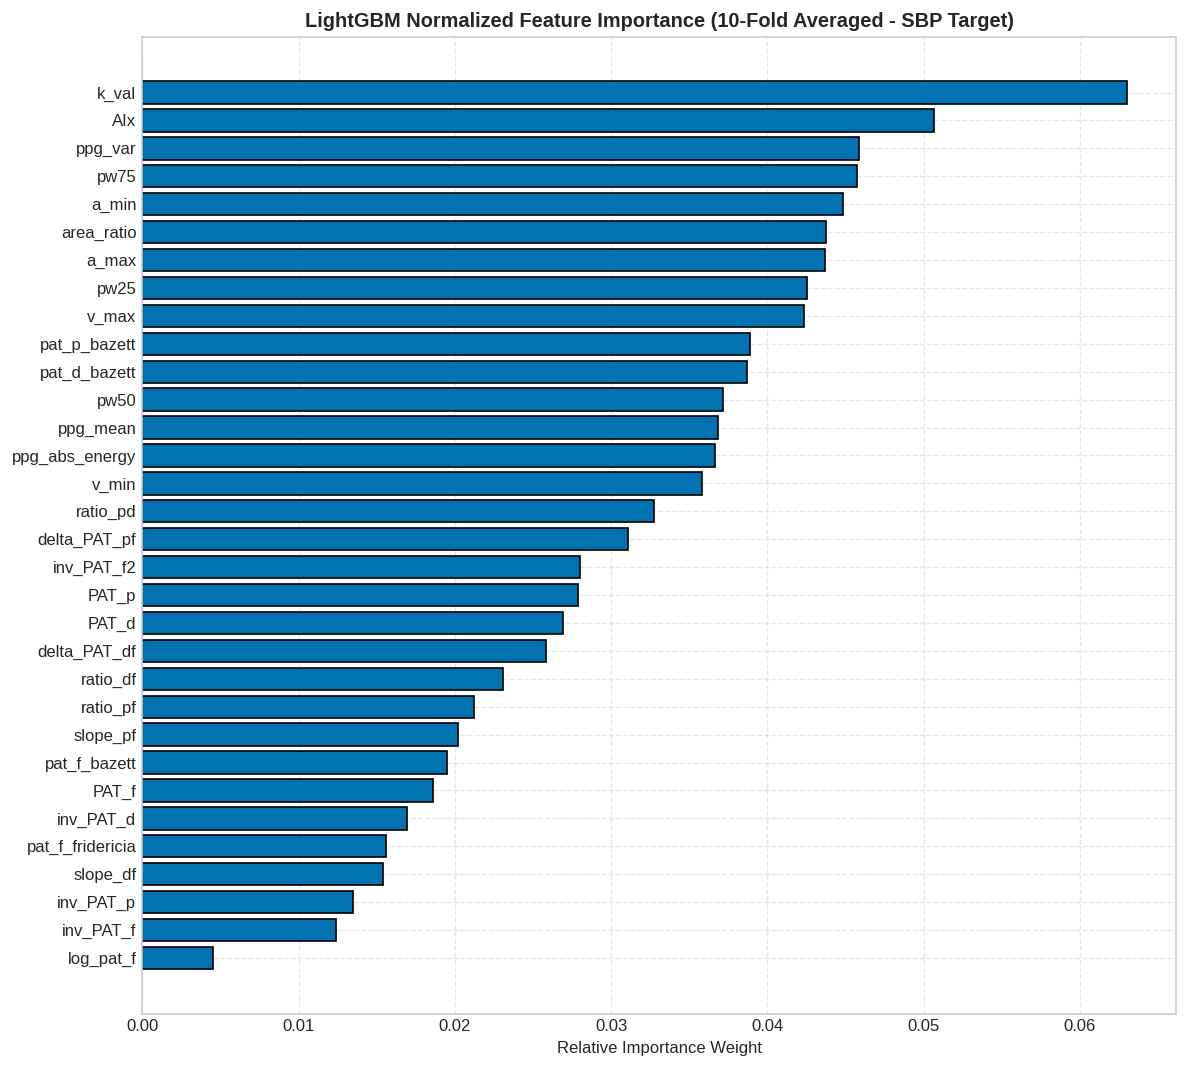

In [7]:
lgbm_imp = np.mean([m.feature_importances_ for m in fold_models_dict['SBP']], axis=0)
lgbm_imp_norm = lgbm_imp / np.sum(lgbm_imp)

df_feat = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': lgbm_imp_norm
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(df_feat['Feature'], df_feat['Importance'], color='#0072B2', edgecolor='black')
ax.set_title("LightGBM Normalized Feature Importance (10-Fold Averaged - SBP Target)", fontsize=12, fontweight='bold')
ax.set_xlabel("Relative Importance Weight")
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("../plots/lightgbm_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()


## Step 8: Export Trained Models & Signal Processor to C for ESP32 Deployment (via `m2cgen`)


In [8]:
DEPLOY_DIR = "../deploy"
os.makedirs(DEPLOY_DIR, exist_ok=True)

final_c_models = {}
for target in ['SBP', 'DBP', 'MAP']:
    y_full = df_all[target].values
    best_p_c = best_lgbm_params[target].copy()
    best_p_c.update({'random_state': 42, 'verbose': -1})
    m_c = LGBMRegressor(**best_p_c).fit(X, y_full)
    final_c_models[target] = m_c

sbp_c = m2c.export_to_c(final_c_models['SBP'], function_name='predict_sbp')
dbp_c = m2c.export_to_c(final_c_models['DBP'], function_name='predict_dbp')
map_c = m2c.export_to_c(final_c_models['MAP'], function_name='predict_map')

with open(os.path.join(DEPLOY_DIR, "lgbm_sbp.c"), "w") as f:
    f.write("// LGBM SBP Model C Code\n#include \"lgbm_sbp.h\"\n#include <math.h>\n\n" + sbp_c + "\n")

with open(os.path.join(DEPLOY_DIR, "lgbm_dbp.c"), "w") as f:
    f.write("// LGBM DBP Model C Code\n#include \"lgbm_dbp.h\"\n#include <math.h>\n\n" + dbp_c + "\n")

with open(os.path.join(DEPLOY_DIR, "lgbm_map.c"), "w") as f:
    f.write("// LGBM MAP Model C Code\n#include \"lgbm_map.h\"\n#include <math.h>\n\n" + map_c + "\n")

print("Successfully exported m2cgen C code for LightGBM SBP, DBP, MAP to ../deploy/")


Successfully exported m2cgen C code for LightGBM SBP, DBP, MAP to ../deploy/
